In [8]:
import time
import matplotlib.pyplot as plt

In [9]:
# 1. Наивный поиск (Brute Force) - O(n * m)
def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    res = []
    for i in range(n - m + 1):
        if text[i:i+m] == pattern:
            res.append(i)
    return res

In [10]:
# 2. Алгоритм Кнута-Морриса-Пратта (KMP) - O(n + m)
def kmp_search(text, pattern):
    def compute_prefix(p):
        m = len(p)
        pi = [0] * m
        k = 0
        for q in range(1, m):
            while k > 0 and p[k] != p[q]:
                k = pi[k-1]
            if p[k] == p[q]:
                k += 1
            pi[q] = k
        return pi

    n, m = len(text), len(pattern)
    pi = compute_prefix(pattern)
    q = 0
    res = []
    for i in range(n):
        while q > 0 and pattern[q] != text[i]:
            q = pi[q-1]
        if pattern[q] == text[i]:
            q += 1
        if q == m:
            res.append(i - m + 1)
            q = pi[q-1]
    return res

In [11]:
# 3. Алгоритм Рабина-Карпа (Rabin-Karp) - O(n + m) в среднем
def rabin_karp_search(text, pattern, d=256, q=101):
    n, m = len(text), len(pattern)
    h = pow(d, m-1) % q
    p = 0
    t = 0
    res = []
    for i in range(m):
        p = (d * p + ord(pattern[i])) % q
        t = (d * t + ord(text[i])) % q
    for s in range(n - m + 1):
        if p == t:
            if text[s:s+m] == pattern:
                res.append(s)
        if s < n - m:
            t = (d * (t - ord(text[s]) * h) + ord(text[s+m])) % q
            t = (t + q) % q
    return res

In [12]:
# 4. Алгоритм Бойера-Мура (Упрощенный - правило плохой эвристики) - O(n/m) в лучшем
def boyer_moore_search(text, pattern):
    m = len(pattern)
    n = len(text)
    if m == 0: return []
    
    # Таблица смещений (плохой символ)
    bad_char = {pattern[i]: i for i in range(m)}
    
    res = []
    s = 0
    while s <= n - m:
        j = m - 1
        while j >= 0 and pattern[j] == text[s + j]:
            j -= 1
        if j < 0:
            res.append(s)
            s += (m - bad_char.get(text[s + m], -1)) if s + m < n else 1
        else:
            s += max(1, j - bad_char.get(text[s + j], -1))
    return res

In [13]:
def run_benchmarks():
    # Генерируем длинную строку для теста (100к символов)
    big_text = "ABC" * 30000 + "SEARCH_ME" + "ABC" * 10000
    pattern = "SEARCH_ME"
    
    methods = [
        ("Naive", naive_search),
        ("KMP", kmp_search),
        ("Rabin-Karp", rabin_karp_search),
        ("Boyer-Moore", boyer_moore_search)
    ]
    
    results = {}
    
    print(f"{'Алгоритм':<15} | {'Время (мс)':<10}")
    print("-" * 30)
    
    for name, func in methods:
        start = time.perf_counter()
        func(big_text, pattern)
        end = time.perf_counter()
        elapsed = (end - start) * 1000
        results[name] = elapsed
        print(f"{name:<15} | {elapsed:.4f}")

    # Визуализация
    plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
    plt.ylabel('Время выполнения (мс)')
    plt.title('Сравнение алгоритмов поиска подстроки')
    plt.show()

Алгоритм        | Время (мс)
------------------------------
Naive           | 9.8843
KMP             | 6.7799
Rabin-Karp      | 23.9739
Boyer-Moore     | 5.2222


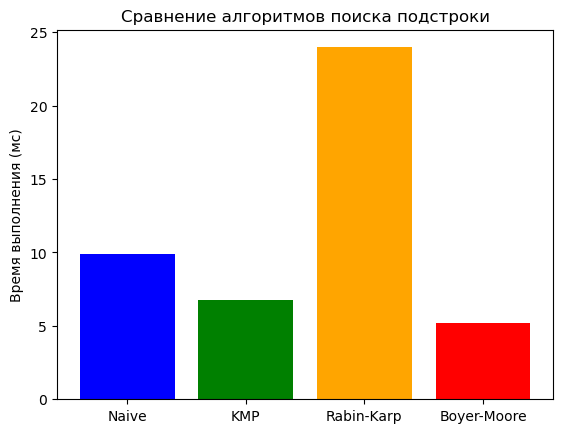

In [14]:
run_benchmarks()